In [1]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler


In [2]:


# =========================================================
# 1. LOAD DATASET
# =========================================================

df = pd.read_csv("Wholesale customers data.csv")

print("Dataset shape:", df.shape)
print(df.head())



Dataset shape: (440, 8)
   Channel  Region  Fresh  Milk  Grocery  Frozen  Detergents_Paper  Delicassen
0        2       3  12669  9656     7561     214              2674        1338
1        2       3   7057  9810     9568    1762              3293        1776
2        2       3   6353  8808     7684    2405              3516        7844
3        1       3  13265  1196     4221    6404               507        1788
4        2       3  22615  5410     7198    3915              1777        5185


In [3]:

# =========================================================
# 2. CHECK DATA QUALITY
# =========================================================

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

print("\nData types:")
print(df.dtypes)




Missing values:
Channel             0
Region              0
Fresh               0
Milk                0
Grocery             0
Frozen              0
Detergents_Paper    0
Delicassen          0
dtype: int64

Duplicate rows: 0

Data types:
Channel             int64
Region              int64
Fresh               int64
Milk                int64
Grocery             int64
Frozen              int64
Detergents_Paper    int64
Delicassen          int64
dtype: object


In [4]:

# =========================================================
# 3. SELECT FEATURES FOR DBSCAN
# =========================================================

# Channel and Region are categorical codes.
# For our first DBSCAN experiment, we will cluster customers
# based only on their spending behaviour.

features = [
    "Fresh",
    "Milk",
    "Grocery",
    "Frozen",
    "Detergents_Paper",
    "Delicassen"
]

X = df[features].copy()

print("\nSelected features:")
print(X.head())




Selected features:
   Fresh  Milk  Grocery  Frozen  Detergents_Paper  Delicassen
0  12669  9656     7561     214              2674        1338
1   7057  9810     9568    1762              3293        1776
2   6353  8808     7684    2405              3516        7844
3  13265  1196     4221    6404               507        1788
4  22615  5410     7198    3915              1777        5185


In [5]:

# =========================================================
# 4. HANDLE MISSING VALUES
# =========================================================

# According to the metadata there are no missing values.
# Still, this check makes the preprocessing pipeline safer.

if X.isnull().sum().sum() > 0:
    X = X.fillna(X.median())



In [6]:

# =========================================================
# 5. HANDLE SKEWED DISTRIBUTIONS
# =========================================================

# Spending columns are strongly right-skewed.
#
# log1p(x) = log(1 + x)
#
# It compresses extremely large values while preserving
# the ordering of observations.
#
# log1p is safer than log because it also supports zero.

X_log = np.log1p(X)

print("\nAfter log transformation:")
print(X_log.head())



After log transformation:
       Fresh      Milk   Grocery    Frozen  Detergents_Paper  Delicassen
0   9.446992  9.175438  8.930891  5.370638          7.891705    7.199678
1   8.861917  9.191259  9.166284  7.474772          8.099858    7.482682
2   8.756840  9.083529  8.947026  7.785721          8.165364    8.967632
3   9.492960  7.087574  8.348064  8.764834          6.230481    7.489412
4  10.026413  8.596189  8.881697  8.272826          7.483244    8.553718


In [8]:
print(X_log.describe())

            Fresh        Milk     Grocery      Frozen  Detergents_Paper  \
count  440.000000  440.000000  440.000000  440.000000        440.000000   
mean     8.732813    8.121615    8.442205    7.303128          6.791781   
std      1.470618    1.080635    1.111523    1.281888          1.709519   
min      1.386294    4.025352    1.386294    3.258097          1.386294   
25%      8.048378    7.335633    7.675081    6.611024          5.551989   
50%      9.048404    8.196435    8.467267    7.331043          6.706242   
75%      9.737123    8.880619    9.273948    8.176177          8.274596   
max     11.627610   11.205027   11.437997   11.016496         10.617123   

       Delicassen  
count  440.000000  
mean     6.671094  
std      1.293960  
min      1.386294  
25%      6.014321  
50%      6.873680  
75%      7.507278  
max     10.777789  


In [9]:


# =========================================================
# 6. FEATURE SCALING
# =========================================================

# DBSCAN calculates distances between observations.
# Therefore features must be on comparable scales.

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_log)


# Convert back to DataFrame for easier inspection
X_scaled = pd.DataFrame(
    X_scaled,
    columns=features,
    index=df.index
)

print("\nScaled data:")
print(X_scaled.head())




Scaled data:
      Fresh      Milk   Grocery    Frozen  Detergents_Paper  Delicassen
0  0.486184  0.976299  0.440155 -1.509250          0.644143    0.408966
1  0.087889  0.990956  0.652171  0.134052          0.766043    0.627926
2  0.016356  0.891151  0.454687  0.376899          0.804405    1.776833
3  0.517477 -0.957973 -0.084792  1.141574         -0.328712    0.633133
4  0.880631  0.439662  0.395847  0.757322          0.404939    1.456588


In [10]:

# =========================================================
# 7. FINAL CHECK
# =========================================================

print("\nFinal shape:", X_scaled.shape)

print("\nMean after scaling:")
print(X_scaled.mean().round(3))

print("\nStandard deviation after scaling:")
print(X_scaled.std().round(3))


Final shape: (440, 6)

Mean after scaling:
Fresh               0.0
Milk               -0.0
Grocery            -0.0
Frozen              0.0
Detergents_Paper   -0.0
Delicassen         -0.0
dtype: float64

Standard deviation after scaling:
Fresh               1.001
Milk                1.001
Grocery             1.001
Frozen              1.001
Detergents_Paper    1.001
Delicassen          1.001
dtype: float64


In [11]:
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt
import numpy as np


In [12]:


# =========================================================
# 1. CHOOSE min_samples
# =========================================================

# We have 6 features.
# A common starting point is:
# min_samples = 2 * number_of_features

n_features = X_scaled.shape[1]

min_samples = 2 * n_features

print("Number of features:", n_features)
print("Selected min_samples:", min_samples)



Number of features: 6
Selected min_samples: 12


In [13]:

# =========================================================
# 2. FIND NEAREST NEIGHBORS
# =========================================================

neighbors = NearestNeighbors(
    n_neighbors=min_samples
)

neighbors_fit = neighbors.fit(X_scaled)



In [14]:

# =========================================================
# 3. CALCULATE DISTANCES
# =========================================================

distances, indices = neighbors_fit.kneighbors(X_scaled)

print("Distances shape:", distances.shape)



Distances shape: (440, 12)


In [18]:

# =========================================================
# 4. GET K-th NEAREST NEIGHBOR DISTANCE
# =========================================================

# We only need the distance to the farthest neighbor
# among the min_samples nearest neighbors.

k_distances = distances[:, -1]

# Sort distances from smallest to largest
k_distances = np.sort(k_distances)
print(k_distances)



[0.67740551 0.68268655 0.68961937 0.70470085 0.73168751 0.73395771
 0.73406595 0.7354586  0.73769342 0.74428297 0.75330165 0.7648695
 0.76935783 0.77210243 0.77449233 0.77526778 0.78057066 0.78135302
 0.78296389 0.78317324 0.78472967 0.78834968 0.79196939 0.79565921
 0.80994354 0.81158285 0.81174049 0.81278493 0.81525005 0.81813347
 0.82036077 0.83054657 0.83074313 0.83235609 0.8327246  0.83805474
 0.83993322 0.84771899 0.85127181 0.85162693 0.85274713 0.85467916
 0.8571294  0.85795507 0.85979879 0.86042822 0.86210963 0.86284772
 0.86595357 0.87699628 0.87926056 0.88533331 0.88732823 0.89067009
 0.89094276 0.89397002 0.89612774 0.89672837 0.89714388 0.89999313
 0.90337361 0.90480063 0.90654102 0.90693344 0.90693344 0.90920292
 0.91079872 0.91319538 0.91349447 0.91436785 0.91658359 0.91859897
 0.92204026 0.9242017  0.929838   0.93388063 0.93802911 0.94139917
 0.94142209 0.9416728  0.94168159 0.94237363 0.94237363 0.9436787
 0.94551564 0.94562893 0.94562893 0.9467499  0.95014522 0.951313

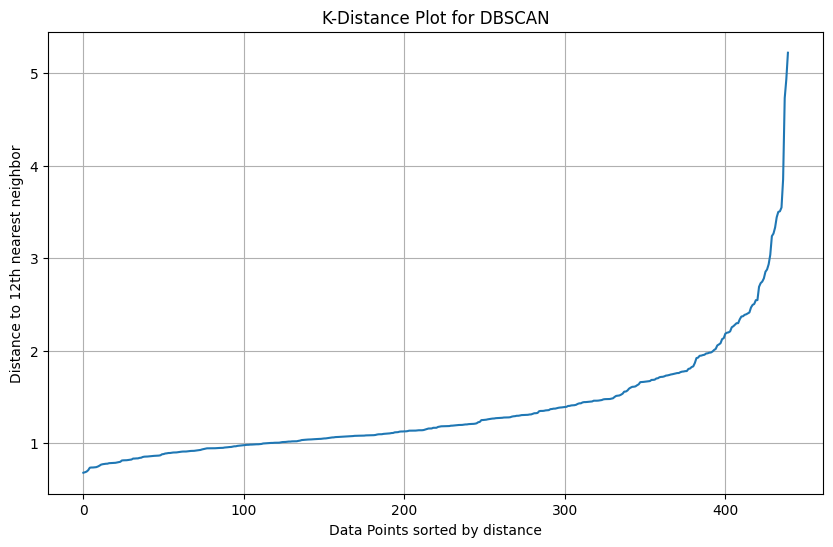

In [16]:

# =========================================================
# 5. K-DISTANCE PLOT
# =========================================================

plt.figure(figsize=(10, 6))

plt.plot(k_distances)

plt.xlabel("Data Points sorted by distance")
plt.ylabel(f"Distance to {min_samples}th nearest neighbor")
plt.title("K-Distance Plot for DBSCAN")

plt.grid()

plt.show()

In [39]:
X_scaled

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,0.486184,0.976299,0.440155,-1.509250,0.644143,0.408966
1,0.087889,0.990956,0.652171,0.134052,0.766043,0.627926
2,0.016356,0.891151,0.454687,0.376899,0.804405,1.776833
3,0.517477,-0.957973,-0.084792,1.141574,-0.328712,0.633133
4,0.880631,0.439662,0.395847,0.757322,0.404939,1.456588
...,...,...,...,...,...,...
435,1.066222,1.181548,1.116754,1.702540,-0.926632,0.794891
436,1.255565,-0.791906,-1.623340,0.867791,-1.316771,0.843179
437,0.579528,1.413991,1.688657,-0.953514,1.647619,0.666566
438,0.344609,-0.490783,-0.658498,-0.278901,-0.973241,0.766663


In [19]:
from sklearn.cluster import DBSCAN
import numpy as np


In [37]:
eps_values = [0.8, 1.0, 1.2, 1.4, 1.6, 1.8]

for eps in eps_values:

    model = DBSCAN(
        eps=eps,
        min_samples=12
    )

    labels = model.fit_predict(X_scaled)

    # Number of clusters, excluding noise (-1)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)

    # Number of noise points
    n_noise = np.sum(labels == -1)

    print(
        f"eps={eps:.1f} | "
        f"clusters={n_clusters} | "
        f"noise={n_noise}"
    )

eps=0.8 | clusters=2 | noise=346
eps=1.0 | clusters=1 | noise=183
eps=1.2 | clusters=1 | noise=105
eps=1.4 | clusters=1 | noise=67
eps=1.6 | clusters=1 | noise=42
eps=1.8 | clusters=1 | noise=27


In [38]:
eps_values = np.arange(0.80, 1.01, 0.02)

for eps in eps_values:

    model = DBSCAN(
        eps=eps,
        min_samples=12
    )

    labels = model.fit_predict(X_scaled)

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = np.sum(labels == -1)

    noise_percentage = (n_noise / len(labels)) * 100

    print(
        f"eps={eps:.2f} | "
        f"clusters={n_clusters} | "
        f"noise={n_noise} ({noise_percentage:.1f}%)"
    )

eps=0.80 | clusters=2 | noise=346 (78.6%)
eps=0.82 | clusters=2 | noise=333 (75.7%)
eps=0.84 | clusters=2 | noise=323 (73.4%)
eps=0.86 | clusters=2 | noise=298 (67.7%)
eps=0.88 | clusters=2 | noise=284 (64.5%)
eps=0.90 | clusters=2 | noise=273 (62.0%)
eps=0.92 | clusters=2 | noise=255 (58.0%)
eps=0.94 | clusters=2 | noise=252 (57.3%)
eps=0.96 | clusters=1 | noise=217 (49.3%)
eps=0.98 | clusters=1 | noise=205 (46.6%)
eps=1.00 | clusters=1 | noise=183 (41.6%)


In [41]:
eps_values = [0.6, 0.7, 0.8, 0.9, 1.0, 1.1, 1.2]
min_samples_values = [3 ,4, 5, 6, 8, 10, 12]


for min_samples in min_samples_values:

    print(f"\nmin_samples = {min_samples}")
    print("-" * 50)

    for eps in eps_values:

        model = DBSCAN(
            eps=eps,
            min_samples=min_samples
        )

        labels = model.fit_predict(X_scaled)

        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)

        n_noise = np.sum(labels == -1)

        noise_percentage = (n_noise / len(labels)) * 100

        print(
            f"eps={eps:.1f} | "
            f"clusters={n_clusters} | "
            f"noise={noise_percentage:.1f}%"
        )


min_samples = 3
--------------------------------------------------
eps=0.6 | clusters=12 | noise=79.1%
eps=0.7 | clusters=15 | noise=58.0%
eps=0.8 | clusters=8 | noise=40.0%
eps=0.9 | clusters=6 | noise=30.2%
eps=1.0 | clusters=6 | noise=20.7%
eps=1.1 | clusters=3 | noise=16.4%
eps=1.2 | clusters=4 | noise=13.9%

min_samples = 4
--------------------------------------------------
eps=0.6 | clusters=7 | noise=84.5%
eps=0.7 | clusters=13 | noise=66.4%
eps=0.8 | clusters=5 | noise=47.0%
eps=0.9 | clusters=4 | noise=34.3%
eps=1.0 | clusters=1 | noise=25.9%
eps=1.1 | clusters=2 | noise=18.6%
eps=1.2 | clusters=3 | noise=16.1%

min_samples = 5
--------------------------------------------------
eps=0.6 | clusters=7 | noise=87.5%
eps=0.7 | clusters=4 | noise=78.0%
eps=0.8 | clusters=3 | noise=52.3%
eps=0.9 | clusters=3 | noise=36.4%
eps=1.0 | clusters=1 | noise=28.2%
eps=1.1 | clusters=1 | noise=21.8%
eps=1.2 | clusters=1 | noise=18.0%

min_samples = 6
-----------------------------------------

In [42]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score
import numpy as np


candidates = [
    (1.1, 3),
    (1.2, 3),
    (1.1, 4),
    (1.2, 4)
]


for eps, min_samples in candidates:

    model = DBSCAN(
        eps=eps,
        min_samples=min_samples
    )

    labels = model.fit_predict(X_scaled)


    # -----------------------------------------
    # Remove noise points for evaluation
    # -----------------------------------------

    mask = labels != -1

    X_clustered = X_scaled[mask]
    labels_clustered = labels[mask]


    # Number of actual clusters
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)

    # Noise percentage
    noise_percentage = np.mean(labels == -1) * 100


    # -----------------------------------------
    # Calculate evaluation metrics
    # -----------------------------------------

    if n_clusters >= 2:

        silhouette = silhouette_score(
            X_clustered,
            labels_clustered
        )

        db_score = davies_bouldin_score(
            X_clustered,
            labels_clustered
        )

        print(
            f"eps={eps} | "
            f"min_samples={min_samples} | "
            f"clusters={n_clusters} | "
            f"noise={noise_percentage:.1f}% | "
            f"silhouette={silhouette:.3f} | "
            f"DB={db_score:.3f}"
        )

eps=1.1 | min_samples=3 | clusters=3 | noise=16.4% | silhouette=0.122 | DB=0.851
eps=1.2 | min_samples=3 | clusters=4 | noise=13.9% | silhouette=-0.014 | DB=1.009
eps=1.1 | min_samples=4 | clusters=2 | noise=18.6% | silhouette=0.154 | DB=0.956
eps=1.2 | min_samples=4 | clusters=3 | noise=16.1% | silhouette=0.144 | DB=0.847


In [43]:
# =========================================================
# 1. CREATE DBSCAN MODEL
# =========================================================

dbscan = DBSCAN(
    eps=1.2,
    min_samples=4
)


In [44]:
# =========================================================
# 2. TRAIN MODEL AND GET CLUSTER LABELS
# =========================================================
labels = dbscan.fit_predict(X_scaled)

In [46]:
# =========================================================
# 3. ADD CLUSTER LABELS TO ORIGINAL DATASET
# =========================================================
df["Cluster"] = labels
df.head()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen,Cluster
0,2,3,12669,9656,7561,214,2674,1338,0
1,2,3,7057,9810,9568,1762,3293,1776,0
2,2,3,6353,8808,7684,2405,3516,7844,0
3,1,3,13265,1196,4221,6404,507,1788,0
4,2,3,22615,5410,7198,3915,1777,5185,0


In [47]:
df["Cluster"].unique()

array([ 0, -1,  1,  2])

In [48]:

# =========================================================
# 4. CHECK UNIQUE CLUSTERS
# =========================================================
unique_labels = np.unique(labels)

print("\nUnique labels:")
print(unique_labels)




Unique labels:
[-1  0  1  2]


In [49]:
# =========================================================
# 5. NUMBER OF CLUSTERS
# =========================================================

# DBSCAN uses -1 for noise/outlier points,
# so we don't count -1 as a cluster.
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
print("\nNumber of clusters:", n_clusters)



Number of clusters: 3


In [50]:

# =========================================================
# 6. NUMBER OF NOISE POINTS
# =========================================================

n_noise = np.sum(labels == -1)

print("Number of noise points:", n_noise)



Number of noise points: 71


In [ ]:

# =========================================================
# 7. NOISE PERCENTAGE
# =========================================================
noise_percentage = (n_noise / len(labels)) * 100
print(f"Noise percentage: {noise_percentage:.2f}%")



Noise percentage: 16.14%


In [52]:

# =========================================================
# 8. NUMBER OF POINTS IN EACH CLUSTER
# =========================================================

print("\nPoints in each cluster:")
print(df["Cluster"].value_counts().sort_index())


Points in each cluster:
Cluster
-1     71
 0    364
 1      4
 2      1
Name: count, dtype: int64


In [53]:
# =========================================================
# 10. REMOVE NOISE POINTS FOR EVALUATION
# =========================================================

mask = labels != -1

X_clustered = X_scaled[mask]
labels_clustered = labels[mask]


print("Total data points:", len(labels))
print("Clustered data points:", len(labels_clustered))
print("Noise points:", np.sum(labels == -1))

Total data points: 440
Clustered data points: 369
Noise points: 71


In [54]:
# =========================================================
# 11. SILHOUETTE SCORE
# =========================================================

from sklearn.metrics import silhouette_score

silhouette = silhouette_score(
    X_clustered,
    labels_clustered
)

print(f"Silhouette Score: {silhouette:.3f}")

Silhouette Score: 0.144


In [55]:
# =========================================================
# 12. DAVIES-BOULDIN SCORE
# =========================================================

from sklearn.metrics import davies_bouldin_score

db_score = davies_bouldin_score(
    X_clustered,
    labels_clustered
)

print(f"Davies-Bouldin Score: {db_score:.3f}")

Davies-Bouldin Score: 0.847


In [56]:
# =========================================================
# 13. FINAL EVALUATION SUMMARY
# =========================================================

print("=" * 45)
print("DBSCAN MODEL EVALUATION")
print("=" * 45)

print(f"eps                  : {dbscan.eps}")
print(f"min_samples          : {dbscan.min_samples}")
print(f"Number of clusters   : {n_clusters}")
print(f"Noise points         : {n_noise}")
print(f"Noise percentage     : {noise_percentage:.2f}%")
print(f"Silhouette Score     : {silhouette:.3f}")
print(f"Davies-Bouldin Score : {db_score:.3f}")

DBSCAN MODEL EVALUATION
eps                  : 1.2
min_samples          : 4
Number of clusters   : 3
Noise points         : 71
Noise percentage     : 16.14%
Silhouette Score     : 0.144
Davies-Bouldin Score : 0.847


In [57]:

cluster_avg = df.groupby("Cluster")[features].mean()

print("Average spending by cluster:")
display(cluster_avg.round(2))

Average spending by cluster:


,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
Cluster,,,,,,
-1,12988.21,8968.55,11618.25,3898.93,3756.68,2514.00
0,11849.69,5174.69,7187.26,2948.66,2668.62,1351.60
1,9821.00,5625.00,11714.00,355.50,6397.25,56.75
2,5396.00,7503.00,10646.00,91.00,4167.00,239.00


In [58]:
overall_avg = df[features].mean()

relative_avg = cluster_avg.div(overall_avg)

print("Cluster spending relative to overall average:")
display(relative_avg.round(2))

Cluster spending relative to overall average:


,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
Cluster,,,,,,
-1,1.08,1.55,1.46,1.27,1.30,1.65
0,0.99,0.89,0.90,0.96,0.93,0.89
1,0.82,0.97,1.47,0.12,2.22,0.04
2,0.45,1.29,1.34,0.03,1.45,0.16


In [59]:
# =========================================================
# 14. PCA FOR 2D VISUALIZATION
# =========================================================

from sklearn.decomposition import PCA


In [60]:


pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)


print("Original shape:", X_scaled.shape)
print("PCA shape:", X_pca.shape)

print(
    "Explained variance:",
    pca.explained_variance_ratio_
)

print(
    "Total explained variance:",
    pca.explained_variance_ratio_.sum()
)

Original shape: (440, 6)
PCA shape: (440, 2)
Explained variance: [0.44077752 0.27194917]
Total explained variance: 0.7127266893428759


In [61]:
# =========================================================
# 15. VISUALIZE DBSCAN CLUSTERS
# =========================================================

import matplotlib.pyplot as plt


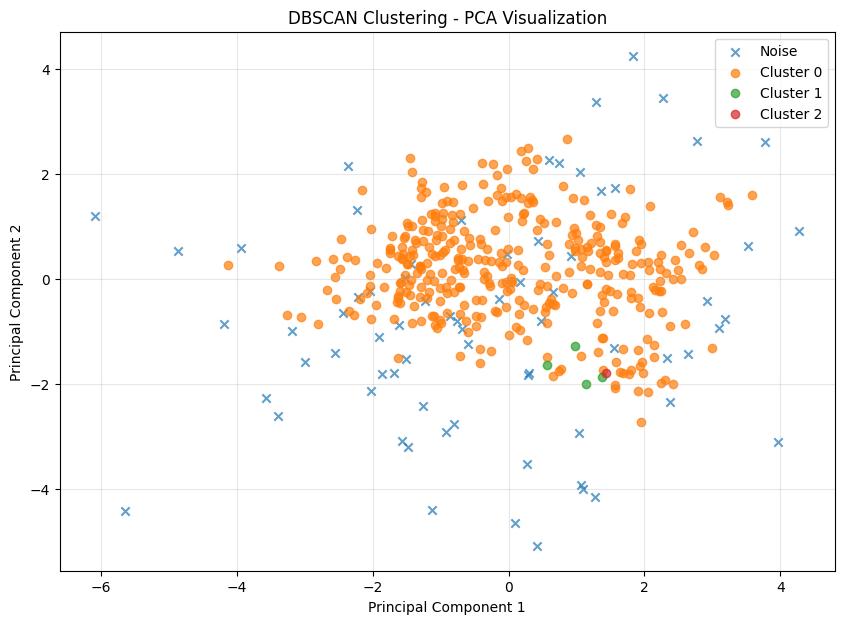

In [62]:


plt.figure(figsize=(10, 7))


# Get all unique cluster labels
unique_clusters = np.unique(labels)


for cluster in unique_clusters:

    cluster_mask = labels == cluster

    # Noise points
    if cluster == -1:

        plt.scatter(
            X_pca[cluster_mask, 0],
            X_pca[cluster_mask, 1],
            label="Noise",
            marker="x",
            alpha=0.7
        )

    # Actual clusters
    else:

        plt.scatter(
            X_pca[cluster_mask, 0],
            X_pca[cluster_mask, 1],
            label=f"Cluster {cluster}",
            alpha=0.7
        )


plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.title("DBSCAN Clustering - PCA Visualization")

plt.legend()

plt.grid(alpha=0.3)

plt.show()

In [63]:
# =========================================================
# 16. PCA FEATURE CONTRIBUTIONS
# =========================================================

pca_components = pd.DataFrame(
    pca.components_,
    columns=features,
    index=["PC1", "PC2"]
)

print(pca_components)

        Fresh      Milk   Grocery    Frozen  Detergents_Paper  Delicassen
PC1 -0.105250  0.542329  0.571472 -0.137910          0.550642    0.214469
PC2  0.590359  0.132911 -0.005751  0.589778         -0.070822    0.530022


In [64]:
cluster_names = {
    -1: "Noise / Unusual Customers",
    0: "Typical Customers",
    1: "Grocery & Detergent Focused",
    2: "Milk & Grocery Focused"
}

df["Customer_Segment"] = df["Cluster"].map(cluster_names)

display(
    df[
        [
            "Fresh",
            "Milk",
            "Grocery",
            "Frozen",
            "Detergents_Paper",
            "Delicassen",
            "Cluster",
            "Customer_Segment"
        ]
    ].head(10)
)

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen,Cluster,Customer_Segment
0,12669,9656,7561,214,2674,1338,0,Typical Customers
1,7057,9810,9568,1762,3293,1776,0,Typical Customers
2,6353,8808,7684,2405,3516,7844,0,Typical Customers
3,13265,1196,4221,6404,507,1788,0,Typical Customers
4,22615,5410,7198,3915,1777,5185,0,Typical Customers
5,9413,8259,5126,666,1795,1451,0,Typical Customers
6,12126,3199,6975,480,3140,545,0,Typical Customers
7,7579,4956,9426,1669,3321,2566,0,Typical Customers
8,5963,3648,6192,425,1716,750,0,Typical Customers
9,6006,11093,18881,1159,7425,2098,0,Typical Customers
